---
title: LiDAR-Based Vegetation Clearance Risk Detection for Utility Transmission Corridors
jupyter: python3
python: /opt/anaconda3/python
author: Ian Morris-Sibaja
date: last-modified
execute:
  enabled: false
  
---

## LiDAR-Based Detection and Fire-Scar Validation - Fillmore, CA

### About

![thomas fire image](https://lpforest.org/wp-content/uploads/2017/12/SisarThomas.png)
Image credits: [Sisar Peak Fire Cam, Trending Social Media Star – December 10, 2017](https://lpforest.org/thomas-fire-on-the-los-padres/)

Vegetation encroachment is one of the leading causes of utility-related wildfire ignition in the western United States. Utilities are required under NERC FAC-003 to maintain minimum clearances between transmission infrastructure and vegetation, but inspecting hundreds of miles of corridor is expensive and labor-intensive. This project demonstrates how publicly available LiDAR data can be used to automatically identify vegetation clearance risks along a transmission right-of-way and validate results against an independent spatial control, using a 1 km² corridor near Fillmore, California.

The workflow was implemented as a reproducible Python pipeline using PDAL, GeoPandas, Rasterio, and ArcGIS REST services, allowing the analysis to be rerun on new LiDAR acquisitions with minimal manual intervention. It automates point-cloud normalization, canopy-height modeling, vegetation screening, and spatial validation from raw LiDAR inputs through final exceedance mapping.

On December 4, 2017, a fire ignited near Santa Paula in Ventura County and didn't stop until it had consumed 281,893 acres. The Thomas Fire was ultimately linked to Southern California Edison electrical infrastructure, highlighting the broader wildfire risks associated with transmission and distribution systems. The fire burned for 40 days through the Los Padres National Forest and left a scar visible from satellite for years.

This analysis focuses on a tile just north of Fillmore, at the southern edge of Los Padres National Forest, where two Southern California Edison transmission lines cross the foothills: a 220 kV line to the north and a 66 kV subtransmission line to the south. Both corridors run directly through the Thomas Fire burn scar. Using a publicly available USGS LiDAR tile collected 4–6 months post-fire, the analysis does three things:

- Derives a 1 m canopy height model (CHM) from a normalized LiDAR point cloud
- Flags vegetation exceeding the FAC-003-4 clearance threshold within the right-of-way
- Validates the CHM using the Thomas Fire burn perimeter as a spatial control

**A note on timing:** The LiDAR was collected May–July 2018, approximately 4–6 months after the Thomas Fire (December 2017). Vegetation inside the burn perimeter was suppressed at survey time, so detections here represent a **conservative lower bound** on current encroachment risk. Unburned areas have had another 8 years of growth since.

---

### Import Libraries

In [1]:
#| code-fold: true
#| code-summary: "Import Modules and Set Root Paths"

# Import modules
import sys
from pathlib import Path
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
import contextily as ctx
import rioxarray
import requests
from shapely.geometry import shape, box

ROOT = Path.cwd().parent  # assumes notebook is in notebooks/
sys.path.append(str(ROOT))

from src.data_utils import load_laz, inspect_point_cloud, validate_crs
from src.pdal_runner import check_pdal_available, run_pipeline
from src.chm import rasterize_to_dsm, rasterize_to_dtm, compute_chm
from src.corridor import load_corridor_centerline, buffer_corridor, clip_chm_to_corridor, threshold_exceedance
from src.chm_acc import assess_chm_accuracy

raw_las_path          = ROOT / "data" / "raw" / "socal_sespe_32611.laz"
pipeline_json_path    = ROOT / "pipeline" / "pdal_pipeline.json"
normalized_las_path   = ROOT / "data" / "processed" / "socal_sespe_32611_normalized.laz"
dsm_path              = ROOT / "outputs" / "rasters" / "socal_sespe_32611_dsm.tif"
dtm_path              = ROOT / "outputs" / "rasters" / "socal_sespe_32611_dtm.tif"
chm_path              = ROOT / "outputs" / "rasters" / "socal_sespe_32611_chm.tif"
clipped_chm_path      = ROOT / "outputs" / "rasters" / "socal_sespe_32611_chm_clipped.tif"
fire_perimeter_path   = ROOT / "data" / "raw" / "thomas_fire_perimeter.gpkg"
accuracy_summary_path = ROOT / "outputs" / "tables" / "accuracy_summary.csv"

---

### Explore the Point Cloud

Before building the CHM, we confirm the raw tile matches the expected USGS specification. A density shortfall or wrong CRS would silently corrupt the raster output, and absent Class 2 ground points the DTM step has nothing to work from.

| | Expected |
|---|---|
| Point count | ~5,578,060 |
| CRS | EPSG:32611 |
| Density | ~5.2 pts/m² |
| Classes | 1 (unclassified), 2 (ground), 7 (noise), 18 (high noise) |

In [2]:
las = load_laz(raw_las_path)

inspect_point_cloud(las)

Total points: 5578060
Classification distribution:
  Class 1: 3317104 points
  Class 2: 2256746 points
  Class 7: 4198 points
  Class 18: 12 points
Bounding box:
xmin: 320721.35000000003, xmax: 322478.14
ymin: 3810258.83, ymax: 3810871.84
zmin: 152.08, zmax: 378.18
Estimated point density (pts/m²): 5.179594625105056


In [3]:
validate_crs(las, expected_epsg=32611)

True

All checks pass. Point count (5,578,060) and density (5.18 pts/m²) match the USGS specification. The bounding box (320721–322478 E, 3810258–3810871 N) confirms this is the correct study area tile. Class 2 ground points (2,256,746) are present from the USGS pre-classification, sufficient for the DTM step. CRS validates as EPSG:32611, matching the project coordinate system. The small noise classes (7 and 18) total under 4,300 points and will be filtered before rasterization.

### Ground Classification and Height Normalization

Before we can measure vegetation height, raw elevation must be separated into ground and non-ground returns, then normalized to height-above-ground (HAG). This is done via a two-stage PDAL pipeline.

The first stage uses the Cloth Simulation Filter (CSF). Picture dropping a cloth from the sky over a forest. Instead, the cloth passes straight through the trees as if they weren't there and settles on the bare ground below. Once the cloth comes to rest, the algorithm draws a simple rule: anything close to the cloth is ground; anything standing above it is not. Rigidness controls how much the cloth resists folding into tight terrain features. A stiffer cloth (higher rigidness) smooths over small bumps and is appropriate for gently rolling terrain; a looser one hugs every crevice, better suited to complex mountainous topography.

A rigidness of 2 is the default and still the right choice here: our study area is a chaparral foothill valley with smooth rolling hills.

The second stage runs `hag_nn`, which adds a `HeightAboveGround` dimension to every point by comparing its elevation against the nearest ground returns, giving us the height of each laser return above the local terrain surface rather than above sea level.

Although the raw tile arrived with USGS-classified ground points already present, we reclassify from scratch using a single consistent pipeline. That way, if any classification decision needs to be revisited, every step is traceable and justifiable, rather than hiding behind a black-box output from an upstream workflow.

| Parameter | Value | Rationale |
|---|---|---|
| `rigidness` | 2 | Default; appropriate for sloped but non-mountainous terrain |
| `slope_smooth` | true | Post-processing to smooth cloth on slopes |
| HAG method | `hag_nn` | Nearest-neighbor interpolation from ground returns |

The PDAL pipeline takes the raw data file as input to normalize heights and reclassify ground returns:

In [4]:
#| code-fold: true
#| code-summary: "Run PDAL Pipeline"

# run_pipeline(
#     pipeline_json_path=pipeline_json_path,
#     input_laz=raw_las_path,
#     output_laz=normalized_las_path
# )

After normalization, Class 2 count increased from 2,256,746 → 2,350,027 and the `HeightAboveGround` dimension is confirmed present.

In [5]:
#| code-fold: true
#| code-summary: "Compare Raw and Normalized LAS Data"

raw_las        = load_laz(raw_las_path)
normalized_las = load_laz(normalized_las_path)

raw_df = pd.DataFrame({
    "x": np.array(raw_las.x).flatten(),
    "y": np.array(raw_las.y).flatten(),
    "z": np.array(raw_las.z).flatten(),
    "classification": np.array(raw_las.classification).flatten(),
    "return_number": np.array(raw_las.return_number).flatten(),
    "intensity": np.array(raw_las.intensity).flatten(),
})

normal_df = pd.DataFrame({
    "x": np.array(normalized_las.x).flatten(),
    "y": np.array(normalized_las.y).flatten(),
    "z": np.array(normalized_las.z).flatten(),
    "classification": np.array(normalized_las.classification).flatten(),
    "return_number": np.array(normalized_las.return_number).flatten(),
    "intensity": np.array(normalized_las.intensity).flatten(),
})

print(f"Raw classification counts:\n{raw_df.value_counts('classification')}\n")
print(f"Normalized classification counts:\n{normal_df.value_counts('classification')}\n")
print(f"\nHeight Above Ground Dimension Exists: {(normalized_las.HeightAboveGround).any()}")

Raw classification counts:
classification
1     3317104
2     2256746
7        4198
18         12
Name: count, dtype: int64

Normalized classification counts:
classification
1     3228026
2     2350027
18          7
Name: count, dtype: int64


Height Above Ground Dimension Exists: True


#### Point Cloud - Height Above Ground

With the data confirmed, we can visualize the normalized point cloud colored by height above ground. Based on local knowledge of the area, vegetation here is predominantly younger citrus orchards and ornamental trees, with the occasional chaparral scrub plot, rarely exceeding 20 m. The visualization clips at 25 m, so any return approaching that ceiling is most likely a transmission tower rather than tree canopy.

In [ ]:
#| code-fold: true
#| warning: false
#| code-summary: "Visualize Normalized LiDAR Data"

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

x_arr = np.array(normalized_las.x)
y_arr = np.array(normalized_las.y)
hag   = np.array(normalized_las.HeightAboveGround)

step = len(x_arr) // 50_000
x_s, y_s, hag_s = x_arr[::step], y_arr[::step], np.clip(hag[::step], 0, 25)

fig = plt.figure(figsize=(14, 7), facecolor="#0d0d0d")
ax  = fig.add_subplot(111, projection="3d", facecolor="#0d0d0d")

sc = ax.scatter(x_s, y_s, hag_s, c=hag_s, cmap="plasma", s=1.5, alpha=0.75, linewidths=0)

for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
    pane.fill = False
    pane.set_edgecolor("#2a2a2a")
ax.grid(False)

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.tick_params(colors="#2a2a2a")

ax.set_xlabel("W → E",     fontsize=8, labelpad=4,  color="#666666")
ax.set_ylabel("S → N",     fontsize=8, labelpad=4,  color="#666666")
ax.set_zlabel("Height (m)", fontsize=8, labelpad=6, color="#666666")

ax.view_init(elev=28, azim=-60)
ax.set_box_aspect([3, 1, 0.5])

cb = plt.colorbar(sc, ax=ax, shrink=0.38, pad=0.10)
cb.ax.yaxis.label.set_color("white")
cb.ax.tick_params(colors="white")
cb.outline.set_edgecolor("#444444")

fig.text(0.57, 0.8, "LiDAR Point Cloud: Fillmore, Ventura Co., CA",
         fontsize=12, color="white", fontweight="bold", ha="center", va="top")
plt.show()

The point cloud reveals tree clusters throughout the corridor. Transmission towers and lines appear as the bright yellow points near or at the 25 m clip ceiling, clearly distinguishable from the surrounding vegetation canopy below.

With the normalized point cloud confirmed, we rasterize it to derive the Canopy Height Model (CHM). The DTM (Digital Terrain Model) is computed from ground-classified returns (Class 2), interpolating bare-earth elevation with vegetation and structures removed. The DSM (Digital Surface Model) is rasterized from first returns, capturing the highest surface at each pixel: tree tops, rooftops, and tower structures. Subtracting the two (DSM - DTM) yields the CHM, the height of each surface feature above the local ground level.

In [7]:
#| code-fold: true
#| code-summary: "Rasterize Normalized LiDAR Data"

# Rasterize the point cloud to create digital surface and terrain models
rasterize_to_dsm(normalized_las_path, resolution=1.0, output_path=dsm_path)
rasterize_to_dtm(normalized_las_path, resolution=1.0, output_path=dtm_path)
compute_chm(dsm_path=dsm_path, dtm_path=dtm_path, output_path=chm_path)

# Load rasters of DSM, DTM, and CHM to visualize and prepare for corridor analysis
with rasterio.open(dsm_path) as src:
    dsm_data = src.read(1)

with rasterio.open(dtm_path) as src:
    dtm_data = src.read(1)

with rasterio.open(chm_path) as src:
    chm_data = src.read(1)

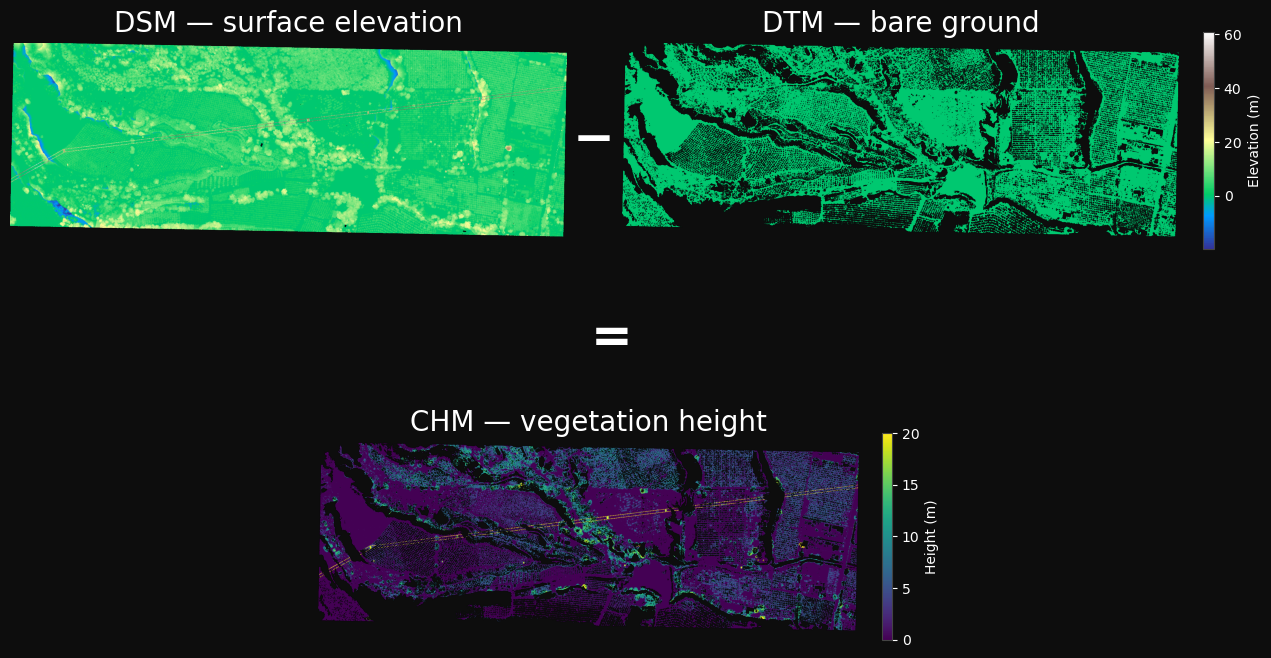

In [8]:
#| code-fold: true
#| code-summary: "Visualize DSM, DTM, and CHM"

import matplotlib.gridspec as gridspec
import numpy as np

BG   = "#0d0d0d"
TEXT = "#ffffff"

_valid_dsm = dsm_data[np.isfinite(dsm_data) & (dsm_data > -9990)]
_valid_dtm = dtm_data[np.isfinite(dtm_data) & (dtm_data > -9990)]
elev_min = min(_valid_dsm.min(), _valid_dtm.min())
elev_max = max(_valid_dsm.max(), _valid_dtm.max())

fig = plt.figure(figsize=(14, 9), facecolor=BG)

# Top row: DSM (left) | DTM (right) — equal-width, symmetric about center
gs_top = gridspec.GridSpec(1, 2, wspace=0.10,
                            left=0.04, right=0.90, top=0.88, bottom=0.52)

ax_dsm = fig.add_subplot(gs_top[0, 0])
im_dsm = ax_dsm.imshow(dsm_data, cmap="terrain", vmin=elev_min, vmax=elev_max)
ax_dsm.set_title("DSM — surface elevation", fontsize=20, pad=8, color=TEXT)
ax_dsm.axis("off")

ax_dtm = fig.add_subplot(gs_top[0, 1])
im_dtm = ax_dtm.imshow(dtm_data, cmap="terrain", vmin=elev_min, vmax=elev_max)
ax_dtm.set_title("DTM — bare ground", fontsize=20, pad=8, color=TEXT)
ax_dtm.axis("off")

cb_top = fig.colorbar(im_dsm, ax=[ax_dsm, ax_dtm], fraction=0.009, pad=0.02,
                      location="right", label="Elevation (m)")
cb_top.ax.yaxis.label.set_color(TEXT)
cb_top.ax.tick_params(colors=TEXT)
cb_top.outline.set_edgecolor("#444444")

# Operator signs as figure text — centered in the gap between panels / rows
fig.text(0.457, 0.70, "−", fontsize=36, ha="center", va="center",
         fontweight="bold", color=TEXT)
fig.text(0.47, 0.48, "=", fontsize=36, ha="center", va="center",
         fontweight="bold", color=TEXT)

# Bottom row: CHM centered, same width as one top panel
gs_bot = gridspec.GridSpec(1, 1, left=0.26, right=0.67, top=0.44, bottom=0.08)

ax_chm = fig.add_subplot(gs_bot[0, 0])
im_chm = ax_chm.imshow(chm_data, cmap="viridis", vmin=0, vmax=20)
ax_chm.set_title("CHM — vegetation height", fontsize=20, pad=8, color=TEXT)
ax_chm.axis("off")

cb_chm = fig.colorbar(im_chm, ax=ax_chm, fraction=0.018, pad=0.04, label="Height (m)")
cb_chm.ax.yaxis.label.set_color(TEXT)
cb_chm.ax.tick_params(colors=TEXT)
cb_chm.outline.set_edgecolor("#444444")

plt.show()

---

### Vegetation Clearance Detection

The CHM is clipped to a 15m buffer around the transmission line centerline and any pixel exceeding the 4.57m (15ft) height threshold is flagged and vectorized into polygon features.

**A note on thresholds:** The 15m corridor buffer and 4.57m height threshold are illustrative and used for the purpose of this exercise only. NERC FAC-003-4 Table 1 sets clearance minimums by voltage class; for 220kV lines the annual minimum is 4.57m (15ft), for 66kV subtransmission it is lower. Actual ROW widths vary by easement. A production analysis would pull these values from utility records before treating any detection as a confirmed exceedance.

Exceedances cluster in two zones: the chaparral foothills on the western side of the tile, where vegetation affected by the Thomas Fire was largely below the clearance threshold at survey time, and the eastern orchard block, where mature citrus encroaches on the 220kV ROW. The western corridor crossing the Thomas Fire burn scar shows almost no exceedances, consistent with the bare-ground CHM in that zone. The 66kV line to the south shows a thin scatter of exceedances; these should be interpreted with caution given the line-detection limitations discussed in the Reflection.

| | |
|---|---|
| Buffer width | 15m (50ft), illustrative, not from utility records |
| Height threshold | 4.57m (15ft), FAC-003-4 annual minimum for 220kV; lower for 66kV |
| Exceedance polygons | 1,547 |
| Mean height | 9.997m |
| Median height | 5.81m |
| Max height | 58.5m |

In [34]:
#| code-fold: true
#| code-summary: Corridor Detection Pipeline and Exceedance Analysis

# --- Corridor Detection Pipeline ---
# Commented out: outputs already computed and saved to disk.
# Re-run if you change the buffer width, height threshold, or input CHM.
# 1. Pull transmission line centerlines from the CEC ArcGIS REST API, clipped to the LiDAR tile extent
# 2. Buffer each centerline by 15m (illustrative ROW width) to define the corridor of interest
# 3. Clip the full-tile CHM to that corridor buffer
# 4. Flag every pixel above the 4.57m clearance threshold and vectorize into exceedance polygons
# Results saved to outputs/vector/flagged_trees.gpkg and outputs/tables/flagged_trees_summary.csv

# url = (
#     "https://services3.arcgis.com/bWPjFyq029ChCGur/arcgis/rest/services"
#     "/Transmission_Line/FeatureServer/2/query"
#     "?outFields=*&where=1%3D1&f=geojson"
# )

# clipped_transmission_lines = load_corridor_centerline(url, normalized_las_path)
# lines_with_buffer          = buffer_corridor(clipped_transmission_lines, buffer_distance_m=15)

# clip_chm_to_corridor(
#     chm_path=chm_path,
#     corridor_gdf=lines_with_buffer,
#     output_path=clipped_chm_path,
# )

# threshold_df = threshold_exceedance(
#     chm_clipped_path=clipped_chm_path,
#     height_threshold_m=4.57,  # 15ft — illustrative, verify against FAC-003-4 for actual voltage class
# )

# # Save exceedance polygons and write summary stats
# threshold_df.to_file(ROOT / "outputs" / "vector" / "flagged_trees.gpkg", driver="GPKG")

threshold_df = gpd.read_file(ROOT / "outputs" / "vector" / "flagged_trees.gpkg")

summary_df = threshold_df[["height_m"]].agg(
    count_exceedance_polygons=("height_m", "count"),
    mean_exceedance_height=("height_m", "mean"),
    median_exceedance_height=("height_m", "median"),
    std_exceedance_height=("height_m", "std"),   
)
summary_df.to_csv(ROOT / "outputs" / "tables" / "flagged_trees_summary.csv")


In [10]:
#| code-fold: true
#| code-summary: "Fetch Thomas Fire Perimeter from ArcGIS REST API"
item_id = "a2926cffbc854806befacbf85ebc9b95"
meta = requests.get(
    f"https://www.arcgis.com/sharing/rest/content/items/{item_id}",
    params={"f": "json"}
).json()
service_url = meta["url"]

# Check field names first with resultRecordCount=1, then filter to Thomas Fire
params = {
    "where": "INC_NUM='00003583'",
    "outFields": "*",
    "f": "geojson",
    "outSR": "32611"
}
query_url = f"{service_url}/0/query?" + "&".join(f"{k}={v}" for k, v in params.items())
thomas_fire = gpd.read_file(query_url).to_crs(epsg=32611)

In [11]:
#| code-fold: true
#| code-summary: "Save Thomas Fire Perimeter to GeoPackage"
thomas_fire.to_file(fire_perimeter_path, driver="GPKG")

#### Interactive Map: Exceedance Polygons and Fire Perimeter

Exceedance polygons colored by `height_m` (plasma) over the fire perimeter. Rendered via folium. Pan, zoom, and hover in the cell output.

In [12]:
#| code-fold: true
#| code-summary: "Render Interactive Exceedance Map (folium)"

import folium
import branca.colormap as bcm
import numpy as np
import matplotlib.cm as mpl_cm
from matplotlib.colors import Normalize

BG   = "#0d0d0d"
TEXT = "#ffffff"

with rasterio.open(chm_path) as src:
    tile_bbox = gpd.GeoDataFrame(geometry=[box(*src.bounds)], crs=src.crs)

thresh_wgs84 = threshold_df.to_crs("EPSG:4326")
fire_wgs84   = thomas_fire.to_crs("EPSG:4326").clip(tile_bbox.to_crs("EPSG:4326"))
bbox_wgs84   = tile_bbox.to_crs("EPSG:4326")
centroid     = tile_bbox.geometry.centroid.to_crs("EPSG:4326").iloc[0]

norm  = Normalize(
    vmin=thresh_wgs84.height_m.quantile(0.05),
    vmax=thresh_wgs84.height_m.quantile(0.95)
)
plasma = mpl_cm.plasma

m_folium = folium.Map(
    location=[centroid.y, centroid.x],
    zoom_start=14,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
)

def exceedance_style(feature):
    h = feature["properties"]["height_m"]
    r, g, b, _ = plasma(norm(np.clip(h, norm.vmin, norm.vmax)))
    return {
        "fillColor": "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255)),
        "color": "#ff6b00",
        "weight": 1,
        "fillOpacity": 0.85,
    }

folium.GeoJson(
    fire_wgs84.__geo_interface__,
    style_function=lambda x: {
        "fillColor": "#b3ac9f",
        "color": "#eb0000",
        "weight": 2,
        "fillOpacity": 0.78,
    },
).add_to(m_folium)

folium.GeoJson(
    bbox_wgs84.__geo_interface__,
    style_function=lambda x: {
        "fillColor": "transparent",
        "color": "#0d0d0d",
        "weight": 3,
        "fillOpacity": 0,
    },
).add_to(m_folium)

folium.GeoJson(
    thresh_wgs84.__geo_interface__,
    style_function=exceedance_style,
    tooltip=folium.GeoJsonTooltip(fields=["height_m"], aliases=["Height (m):"]),
).add_to(m_folium)

# Colorbar
plasma_hex = [
    "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))
    for r, g, b, _ in [plasma(i) for i in np.linspace(0, 1, 10)]
]
colormap = bcm.LinearColormap(
    colors=plasma_hex, vmin=norm.vmin, vmax=norm.vmax,
    caption="Vegetation height (m)"
)
colormap.add_to(m_folium)

# Dark title + legend style overrides
m_folium.get_root().html.add_child(folium.Element(f"""
<style>
  .legend {{ background-color: {BG} !important; color: {TEXT} !important; }}
  .legend .caption {{ color: {TEXT} !important; }}
  .legend svg text {{ fill: {TEXT} !important; }}
</style>
<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);
            z-index:1000;background:{BG};padding:8px 16px;border-radius:4px;
            white-space:nowrap;">
  <span style="font-family:sans-serif;font-size:14px;font-weight:bold;color:{TEXT};">
    Vegetation Exceedances Along Transmission Corridor &middot; Fillmore, Ventura Co., CA
  </span>
</div>
"""))

m_folium

### Validation: The Thomas Fire as a Natural Experiment

Before treating the exceedance detections as operationally meaningful, we need evidence the CHM is actually measuring vegetation correctly. The Thomas Fire provides a natural experiment: burned areas surveyed 4–6 months post-fire should be near-zero; unburned areas should show intact canopy. If that pattern holds, the CHM signal is reliable.

In [13]:
#| code-fold: true
#| code-summary: "Assess CHM Accuracy"

assess_chm_accuracy(
    chm_path=chm_path,
    fire_perimeter_path=fire_perimeter_path,
    output_path=accuracy_summary_path
)

,mean_chm_inside,mean_chm_outside,mean_difference,median_chm_inside,median_chm_outside,median_difference,percent_bare_ground_inside
0,2.003475,2.763293,0.759818,0.0,1.23,1.23,66.309878


The 0.76m mean difference understates the validation signal. The median inside the perimeter is exactly 0.0m, meaning more than half of all burned-zone pixels registered zero canopy height, exactly what burned chaparral four months post-containment should look like. The mean is pulled upward by transmission infrastructure: the 220kV lattice towers cross the Thomas Fire perimeter multiple times, and their 37–49m returns drag the inside-perimeter mean toward 2m even when the surrounding terrain is bare. The 66.3% bare-ground rate (≤0.5m) is the most defensible summary statistic: two-thirds of pixels inside the perimeter registered near-zero canopy, consistent with a near-total burn event. The median difference of 1.23m and the bare-ground rate together confirm the CHM is measuring real vegetation structure, not sensor noise.

| | Inside burn perimeter | Outside burn perimeter |
|---|---|---|
| Mean CHM | 2.003m | 2.763m |
| Median CHM | 0.0m | 1.23m |
| % bare ground (≤0.5m) | 66.3% | — |

The Thomas Fire perimeter overlaps ~221,145 m² of the tile (~20% of total extent), with the perimeter edge running diagonally through the study area, giving both burned and unburned samples within the same tile.

---

### Spatial Regression Discontinuity Validation

| Output | Path |
|---|---|
| Discontinuity plot | `outputs/figures/spatial_rdd_bandwidth_200m.png` |
| Sensitivity table | `outputs/tables/rdd_sensitivity.csv` |

In [14]:
# | code-fold: true
# | code-summary: "Assess CHM Accuracy"

from validation.accuracy_assessment import spatial_rdd

rdd_result = spatial_rdd(
    chm_path=chm_path,
    fire_perimeter_path=fire_perimeter_path,
    bandwidth_m=200,
    output_path=ROOT / "outputs",
)

RDD sensitivity results saved. Check for stability across bandwidths — flag if estimates vary by more than ~20%.


RDD estimate : -0.965 m  (negative = fire reduced height)
Std error    : 0.023 m
95% CI       : [-1.010, -0.921]
Pixels in window: 440,120 at bandwidth=200m


,Bandwidth (m),RDD estimate (m),Standard Error,95th Confidence Interval,5th Confidence Interval,Number of Pixels
0,50,-0.159480,0.038231,-0.084548,-0.234413,165383
1,75,-0.362112,0.034250,-0.294981,-0.429242,230074
2,100,-0.573387,0.030475,-0.513655,-0.633119,284594
3,150,-1.093089,0.025670,-1.042776,-1.143401,369259
4,200,-0.965478,0.022685,-0.921016,-1.009940,440120
5,300,-1.015558,0.019400,-0.977534,-1.053583,552984


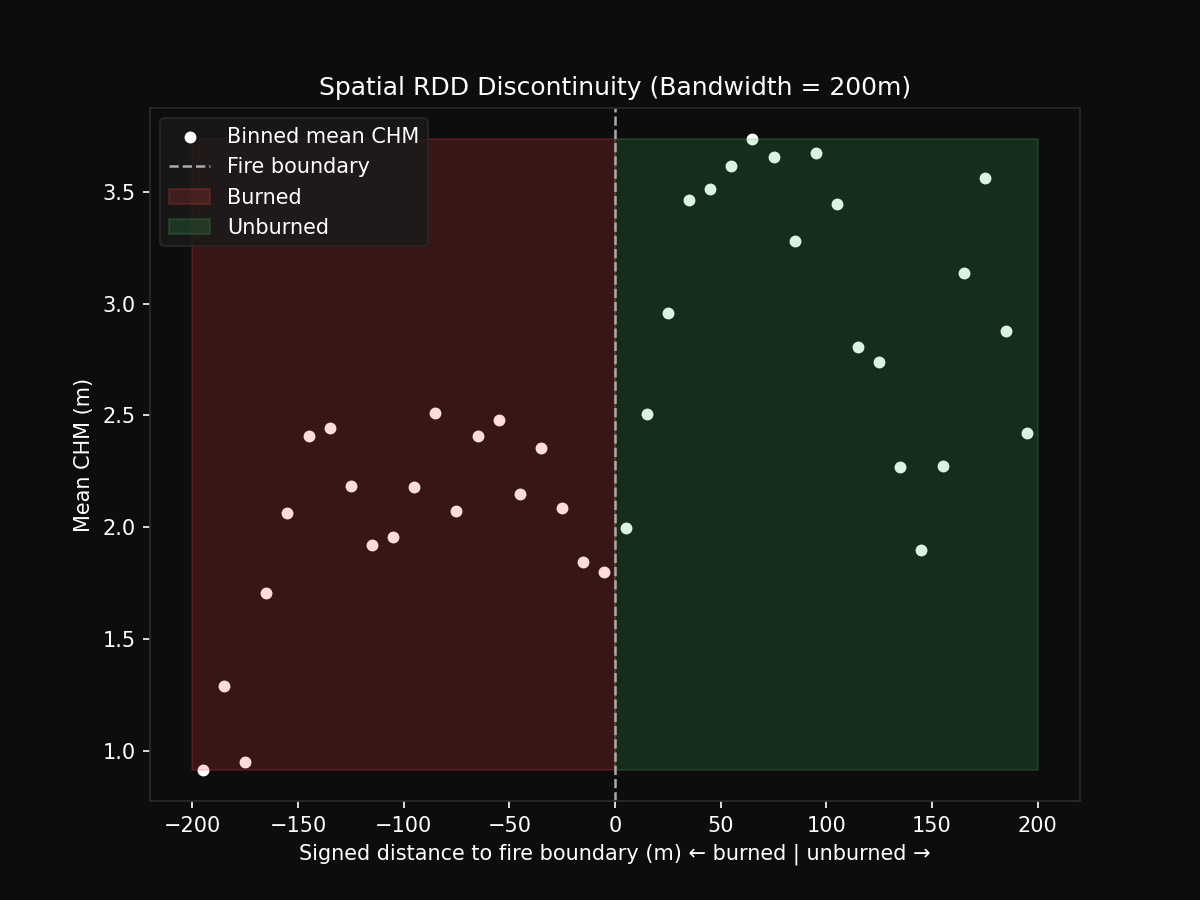

In [15]:
#| code-fold: true
#| code-summary: "RDD Result"

print(f"RDD estimate : {rdd_result['rdd_estimate']:.3f} m  (negative = fire reduced height)")
print(f"Std error    : {rdd_result['se']:.3f} m")
print(f"95% CI       : [{rdd_result['ci_lower']:.3f}, {rdd_result['ci_upper']:.3f}]")
print(f"Pixels in window: {rdd_result['n_pixels']:,} at bandwidth={rdd_result['bandwidth_m']}m")

# Sensitivity across bandwidths (100, 200, 300m) — saved by spatial_rdd()
sens = pd.read_csv(ROOT / "outputs" / "tables" / "rdd_sensitivity.csv")
display(sens)

# Binned discontinuity plot — saved by spatial_rdd()
from IPython.display import Image
display(Image(ROOT / "outputs" / "figures" / f"spatial_rdd_bandwidth_{rdd_result['bandwidth_m']:.0f}m.png"))

To further validate the CHM, canopy heights immediately inside and outside the Thomas Fire perimeter were compared using a spatial regression discontinuity design. The estimated discontinuity at the fire boundary ranged from −0.97m to −1.09m across stable bandwidths, indicating substantially lower vegetation height inside the burn scar. The effect was statistically significant and correctly signed across all specifications, providing independent evidence that the LiDAR-derived canopy heights reflect real vegetation structure rather than sensor artifacts.

In [30]:
summary_df  = gpd.read_file(ROOT / "outputs" / "tables" / "flagged_trees_summary.csv")

summary_df.head()

print(f"Number of exceedance polygons: {summary_df['height_m'].iloc[0]}")
print(f"Mean exceedance height: {float(summary_df['height_m'].iloc[1]):.3f} meters")

Number of exceedance polygons: 1547.0
Mean exceedance height: 9.997 meters


---

### Reflection

This project demonstrates a scalable workflow for identifying vegetation-clearance risks using airborne LiDAR. Within a 1 km² transmission corridor, the analysis automatically identified 1,547 potential exceedance polygons and validated canopy-height estimates against an independent wildfire burn scar. While the thresholds used here are illustrative, the workflow mirrors the core components of operational utility vegetation-management programs: remote sensing, automated risk screening, geospatial prioritization, and regulatory compliance support.

The Thomas Fire validation supports treating these detections as real vegetation signal. Two-thirds (66.3%) of burned-zone pixels registered bare ground (≤0.5m CHM), and the median inside the perimeter is exactly 0.0m, consistent with a near-total burn event four months post-containment. The inside-perimeter mean (2.003m) is elevated by transmission tower returns; the median and bare-ground rate are the defensible metrics. The spatial regression discontinuity analysis provides stronger evidence that the observed difference reflects fire impacts rather than broad spatial trends: at 150m bandwidth the estimated jump at the fire boundary is −1.09m, significant and correctly signed. Exceedances concentrate in the eastern orchard block, where mature citrus encroaches on the 220kV ROW; the western corridor crossing the Thomas Fire burn area shows almost no exceedances, consistent with the near-zero CHM in that zone at survey time.

**Limitations.** Several constraints bound the operational scope of this analysis. The LiDAR was collected in 2018 and is now 8 years old; the 1,547 detections represent a conservative lower bound on current encroachment risk. The 15m corridor buffer and 4.57m height threshold are illustrative, not drawn from utility easement records or voltage-class-specific FAC-003-4 clearance tables. The Thomas Fire perimeter overlaps only ~20% of the tile, so the validation sample is partial and concentrated at the western edge; the eastern orchard zone has no fire-scar ground truth. LiDAR-based line detection is reliable for the 220kV lattice towers but degrades for the 66kV subtransmission line at 5.2 pts/m² density; exceedances along the 66kV corridor should be interpreted with caution.

**Future work.** A complete operational analysis would require:

1. **Updated height data.** This 2018 survey is 8 years old. A new 3DEP acquisition of the corridor would be preferred; GEDI or ICESat-2 could provide a recent canopy height snapshot at lower spatial resolution.
2. **Voltage-class-specific thresholds.** FAC-003-4 Table 1 clearance minimums vary by voltage class. A production analysis would pull buffer widths and thresholds from the utility's actual easement records.
3. **Operational prioritization.** Future versions could rank exceedances by combining vegetation height, distance to conductors, terrain accessibility, fire risk, and asset criticality to support field inspection scheduling.
4. **Multi-tile coverage.** This 1.08 km² tile captures one corridor segment. The full SCE corridor runs tens of kilometers and would require tiling and mosaicking to assess at scale.
5. **Comparison against inspection records.** Ground-truthing LiDAR-flagged polygons against utility vegetation inspection records would establish detection precision and identify false-positive sources such as towers and rooftops.

---

### Citations

| Data | Citation |
|---|---|
| USGS 3DEP LiDAR | U.S. Geological Survey, 3D Elevation Program. *SoCal Wildfires B3 2018 QL1 LiDAR.* Accessed via The National Map. |
| CA Transmission Lines | California Energy Commission. *Electric Transmission Lines.* ArcGIS REST API. `services3.arcgis.com/bWPjFyq029ChCGur` |
| Thomas Fire Perimeter | CAL FIRE. *California Fire Perimeters.* ArcGIS REST API, item `a2926cffbc854806befacbf85ebc9b95` |
| NERC Standard | North American Electric Reliability Corporation. *FAC-003-4: Transmission Vegetation Management.* 2016. |